# NLS1 宿主星系測光紅移 (Photometric Redshift) 計算管線

本管線利用 Pan-STARRS1 (PS1) 的測光資料，透過 `eazy-py` (Template Fitting) 函式庫計算窄線塞弗特1型 (NLS1) 宿主星系的測光紅移 ($z_{phot}$)。

## 方法概述：
1. **銀河系消光校正**：使用 Schlafly & Finkbeiner (2011) 的消光係數。
2. **AB 星等轉通量**：將校正後的星等轉換為微央斯基 ($\mu\text{Jy}$)。
3. **EAZY-Py 設置**：包含 AGN/QSO 模板 (`tweak_fsps_QSF_v12.param`) 並設定 $r$ 波段先驗。
4. **$\chi^2$ 最小化與機率分佈**：計算最佳擬合紅移與完整機率分佈函數 $P(z)$。

In [1]:
import numpy as np
import pandas as pd
from astropy.table import Table
import eazy
import os
from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
import astropy.units as u
import eazy.photoz

# 確保 EAZY 模板目錄存在 (若有自訂路徑請修改)
# os.environ['EAZYCODE'] = '/path/to/eazy-photoz'

## 定義管線主函數
這個函數包含了從資料前處理（消光校正、通量轉換）到執行 EAZY 模板擬合的所有核心邏輯。

In [2]:
def run_nls1_photoz_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    為 NLS1 宿主星系執行 EAZY-Py 測光紅移計算管線。
    
    預期輸入 DataFrame (df) 包含以下欄位：
    - '{band}_MeanApMag': g, r, i, z, y 波段的 AB 星等
    - '{band}_MeanApMagErr': 對應的星等誤差
    - 'ebv': E(B-V) 銀河系消光值
    """
    print("開始執行 NLS1 測光紅移管線...")
    
    # 複製 DataFrame 以避免覆寫原始資料
    results_df = df.copy()
    if 'id' not in results_df.columns:
        results_df['id'] = np.arange(len(results_df))
        
    # 定義 PS1 波段名稱
    bands = ['g', 'r', 'i', 'z', 'y']
    
    # ---------------------------------------------------------
    # 步驟 1: 銀河系消光校正 (Galactic Extinction Correction)
    # ---------------------------------------------------------
    # 依據 Schlafly & Finkbeiner (2011) 的 Pan-STARRS1 係數 (R_V = 3.1)
    extinction_coeffs = {
        'g': 3.172,
        'r': 2.271,
        'i': 1.682,
        'z': 1.322,
        'y': 1.087
    }
    
    # ---------------------------------------------------------
    # 步驟 2: AB 星等轉換為通量密度 (AB Magnitude to Flux Density)
    # ---------------------------------------------------------
    for b in bands:
        mag_col = f'{b}MeanApMag'
        err_col = f'{b}MeanApMagErr'
        flux_col = f'F_{b}'
        ferr_col = f'E_{b}'
        
        # 處理資料中可能的非數值 (NaN) 或極端異常值 (防錯機制)
        # 假設 -999 或 NaN 代表未探測 (Non-detections)
        non_detect_mask = results_df[mag_col].isna() | (results_df[mag_col] < 0) | (results_df[err_col] > 99.0)
        
        # 計算消光量 A_lambda
        A_lambda = extinction_coeffs[b] * results_df['ebv']
        
        # 校正視星等 m_corr = m_obs - A_lambda
        m_corr = results_df[mag_col] - A_lambda
        
        # 將星等轉換為微央斯基 (microJanskys, uJy) 的通量密度
        results_df[flux_col] = 10 ** (-0.4 * (m_corr - 23.9))
        
        # 將星等誤差轉換為通量誤差
        # 誤差傳播: sigma_F = F_nu * (ln(10) / 2.5) * sigma_m
        results_df[ferr_col] = results_df[flux_col] * (np.log(10) / 2.5) * results_df[err_col]
        
        # 處理未探測到的波段以進行 chi^2 最小化 (Flux = 0, Error = 999.0)
        results_df.loc[non_detect_mask, flux_col] = 0.0
        results_df.loc[non_detect_mask, ferr_col] = 999.0

    # 建立 EAZY-Py 預期的 Astropy Table 格式
    # 注意: EAZY 需要將 F_ 和 E_ 後面的字元映射為對應的濾光片 ID (Filter ID)
    # 這裡我們需要知道 PS1 在 EAZY 濾光片檔案 (FILTER.RES.latest) 中的對應 ID。
    # 假設 PS1 g, r, i, z, y 的濾光片 ID 分別為 334, 335, 336, 337, 338 (請根據實際 FILTER.RES 確認)
    ps1_filter_ids = {'g': '334', 'r': '335', 'i': '336', 'z': '337', 'y': '338'}
    
    eazy_input_table = Table()
    eazy_input_table['id'] = results_df['id']
    
    for b in bands:
        filt_id = ps1_filter_ids[b]
        eazy_input_table[f'F{filt_id}'] = results_df[f'F_{b}']
        eazy_input_table[f'E{filt_id}'] = results_df[f'E_{b}']
        
    # 將 Z_SPEC 設定為 -1 表示這些是沒有光譜紅移的目標
    eazy_input_table['z_spec'] = -1.0 
    
    # ---------------------------------------------------------
    # 步驟 3: EAZY-Py 初始化與配置 (EAZY-Py Configuration)
    # ---------------------------------------------------------
    params = {}
    params['Z_MIN'] = 0.01          # 紅移網格下限
    params['Z_MAX'] = 1.5           # 紅移網格上限
    params['Z_STEP'] = 0.01         # 紅移網格步長
    
    # 強制限制模板數量為 4，打破 5 個濾光片的數學簡併！
    params['TEMPLATES_FILE'] = 'templates/eazy_4temp.spectra.param' 

    
    # 先驗設定 (基於 r 波段的 AB 星等先驗)
    params['APPLY_PRIOR'] = 'y'
    params['PRIOR_FILE'] = 'templates/prior_R_zmax7.dat' # 根據需求替換先驗檔案
    params['PRIOR_FILTER'] = int(ps1_filter_ids['r'])    # 設定 r 波段做為先驗參考
    params['PRIOR_ABZP'] = 23.9                          # uJy 系統的零點
    
    # 其他 EAZY 內部參數
    params['FIX_ZSPEC'] = 'n'
    params['IGM_SCALE_TAU'] = 1.0
    
    # 建立一個簡單的 translate 檔案，告訴 EAZY 直接對應我們設定的欄位名稱
    translate_file = 'photz_input.translate'
    with open(translate_file, 'w') as f:
        for col in eazy_input_table.colnames:
            f.write(f'{col} {col}\n')
            
    # 將我們準備好的 Table 寫入實體的 Catalog 檔案
    catalog_file = 'photz_input.cat'
    eazy_input_table.write(catalog_file, format='ascii.commented_header', overwrite=True)
    
    # 將此檔案路徑設定給 EAZY
    params['CATALOG_FILE'] = catalog_file

    # 初始化 PhotoZ 實例
    print("初始化 EAZY PhotoZ 類別...")
    ez = eazy.photoz.PhotoZ(
        param_file=None, 
        translate_file='dummy.translate', 
        zeropoint_file=None, 
        params=params, 
        load_prior=True, 
        load_products=False
    )
    
    # 註: 不需再手動賦值 ez.cat，因為初始化時 PhotoZ 就會自動讀取我們寫的 photz_input.cat

    
    # 設定好後讀取通量
    # ez.unpack_catalog()
    
    # ---------------------------------------------------------
    # 步驟 4: The Chi-Squared Minimization Core (擬合過程)
    # ---------------------------------------------------------
    print("執行 Chi-squared 模板擬合與紅移推導...")
    ez.fit_parallel(n_proc=4)

    # ---------------------------------------------------------
    # 步驟 5: 提取輸出 (Extracting the Output)
    # ---------------------------------------------------------
    print("提取結果參數與機率分佈函數 (PDF)...")
    
    # 1. 取得標準結果 (在新版中回傳的是 tuple)
    output_obj = ez.standard_output()
    
    # 取出 tuple 中的第一個元素 (即 Astropy Table 資料表)
    data_table = output_obj[0] if isinstance(output_obj, tuple) else output_obj
    
    # (防呆機制) 取得欄位名稱列表
    cols = data_table.colnames if hasattr(data_table, 'colnames') else list(data_table.keys())
    print(f"解析到的輸出欄位有: {cols}")
    
    # 2. 將最佳紅移寫回 DataFrame
    if 'z_phot' in cols:
        results_df['z_phot'] = data_table['z_phot']
    elif 'z_a' in cols:
        results_df['z_phot'] = data_table['z_a']
    elif 'z_phot_chi2' in cols:
        results_df['z_phot'] = data_table['z_phot_chi2']
    
    # 判斷 chi-squared 的欄位名稱
    if 'z_phot_chi2' in cols:
        results_df['chi_squared'] = data_table['z_phot_chi2']
    elif 'chi_best' in cols:
        results_df['chi_squared'] = data_table['chi_best']
    elif 'chi_p' in cols:
        results_df['chi_squared'] = data_table['chi_p']
    elif 'chi_a' in cols:
        results_df['chi_squared'] = data_table['chi_a']
    else:
        results_df['chi_squared'] = np.nan    
    
    if 'z500' in cols:
        results_df['z500'] = data_table['z500']

    # 3. 取得 P(z) 機率分佈
    if hasattr(ez, 'lnp'):
        pz_linear = np.exp(ez.lnp)
        results_df['z_pdf_array'] = [pz_linear[i].tolist() for i in range(ez.NOBJ)]
    else:
        print("警告: 找不到機率分佈屬性 (lnp)")
        results_df['z_pdf_array'] = None
    
    print("管線執行完畢。")
    return results_df

## 執行與測試
這是一個如何呼叫上述管線函數的範例。

In [3]:
# 讀取您的資料 (根據您的實際資料集修改)
# 假設資料存放於 photz.data.fits，且您先將其轉成了 DataFrame
# df = Table.read('photz.data.fits').to_pandas()

# 執行管線
# results = run_nls1_photoz_pipeline(df)

# 檢視結果
# print(results[['id', 'z_phot', 'chi_squared']].head())

In [4]:
df = pd.read_csv('../data/merged_training_ps1.csv')[:10000]
sfd = SFDQuery()

coords = SkyCoord(ra = df['raMean'], dec = df['decMean'], frame = 'icrs', unit = (u.deg, u.deg))
ebv = sfd(coords)
df['ebv'] = ebv

In [5]:
results = run_nls1_photoz_pipeline(df)

開始執行 NLS1 測光紅移管線...
初始化 EAZY PhotoZ 類別...
Read default param file: c:\Users\nianz\micromamba\envs\astro13\Lib\site-packages\eazy\data/zphot.param.default
Read CATALOG_FILE: photz_input.cat
   >>> NOBJ = 10000
F334 E334 (334): PAN-STARRS/PS1.g
F335 E335 (335): PAN-STARRS/PS1.r
F336 E336 (336): PAN-STARRS/PS1.i
F337 E337 (337): PAN-STARRS/PS1.z
F338 E338 (338): PAN-STARRS/PS1.y
Set sys_err = 0.01 (positive=True)


c:\Users\nianz\micromamba\envs\astro13\Lib\site-packages\eazy\photoz.py:1330: RuntimeWarning: divide by zero encountered in log10
  self.prior_mag_cat += -2.5*np.log10(np.squeeze(self.fnu[:,ix]))


Read PRIOR_FILE:  templates/prior_R_zmax7.dat
Template grid: templates/eazy_4temp.spectra.param (this may take some time)


100%|██████████| 4/4 [00:05<00:00,  1.43s/it]


Template   0: eazy_v1.0_sed1.dat (NZ=1).
Template   1: eazy_v1.0_sed3.dat (NZ=1).
Template   2: eazy_v1.0_sed5.dat (NZ=1).
Template   3: eazy_v1.0_sed6.dat (NZ=1).
Process templates: 6.173 s


...


 Couldn't find template parameters file templates/eazy_4temp.spectra.param.fits in ['./', 'c:\\Users\\nianz\\micromamba\\envs\\astro13\\Lib\\site-packages\\eazy\\data\\eazy-photoz'] for population synthesis 
 calculations.
            


100%|██████████| 8810/8810 [01:20<00:00, 110.05it/s]


Abs Mag filters [271, 272, 274]
Rest-frame filters:
~~~~~~~~~~~~~~~~~~~ 
   0 RestUV/Tophat_1700_200.dat lambda_c= 1.6989e+03 AB-Vega=1.916 w95=190.7
   1 RestUV/Tophat_2200_200.dat lambda_c= 2.1993e+03 AB-Vega=1.691 w95=191.1
   2 RestUV/Tophat_2800_200.dat lambda_c= 2.7996e+03 AB-Vega=1.465 w95=191.2


100%|██████████| 8810/8810 [00:22<00:00, 398.57it/s]
c:\Users\nianz\micromamba\envs\astro13\Lib\site-packages\eazy\photoz.py:4122: RuntimeWarning: divide by zero encountered in log10
  obsm = self.param.params['PRIOR_ABZP'] - 2.5*np.log10(rf[:,i,:])
c:\Users\nianz\micromamba\envs\astro13\Lib\site-packages\eazy\photoz.py:4122: RuntimeWarning: invalid value encountered in log10
  obsm = self.param.params['PRIOR_ABZP'] - 2.5*np.log10(rf[:,i,:])


解析到的輸出欄位有: ['id', 'z_spec', 'nusefilt', 'z_ml', 'z_ml_chi2', 'z_ml_risk', 'lc_min', 'lc_max', 'z_phot', 'z_phot_chi2', 'z_phot_risk', 'z_min_risk', 'min_risk', 'z_raw_chi2', 'raw_chi2', 'z025', 'z160', 'z500', 'z840', 'z975', 'restU', 'restU_err', 'restB', 'restB_err', 'restV', 'restV_err', 'restJ', 'restJ_err', 'dL', 'mass', 'sfr', 'Lv', 'LIR', 'energy_abs', 'MLv', 'Av', 'mass_p', 'sfr_p', 'Lv_p', 'LIR_p', 'energy_abs_p', 'Av_p', 'ssfr_p', 'rest270', 'rest270_err', 'rest274', 'rest274_err', 'rest120', 'rest120_err', 'rest121', 'rest121_err', 'rest156', 'rest156_err', 'rest157', 'rest157_err', 'rest158', 'rest158_err', 'rest159', 'rest159_err', 'rest160', 'rest160_err', 'rest161', 'rest161_err', 'rest162', 'rest162_err', 'rest163', 'rest163_err', 'DISTMOD', 'ABSM_271', 'ABSM_272', 'ABSM_274']
管線執行完畢。


In [6]:
print(results[['id', 'spec_redshift', 'z_phot', 'chi_squared']][results['z_phot']!=-1])

        id  spec_redshift    z_phot  chi_squared
1        1       0.479246  0.543411     0.806257
2        2       0.863240  0.249589     0.000395
3        3       0.167459  0.381935     7.154354
5        5       0.459811  0.436931    10.719793
6        6       0.784719  0.406224     0.000394
...    ...            ...       ...          ...
9995  9995       0.287425  0.379463     8.221563
9996  9996       0.775355  0.117394     0.000515
9997  9997       0.605113  0.943171     0.647502
9998  9998       0.621140  0.929869     0.102612
9999  9999       0.580315  0.936173    24.778688

[8966 rows x 4 columns]


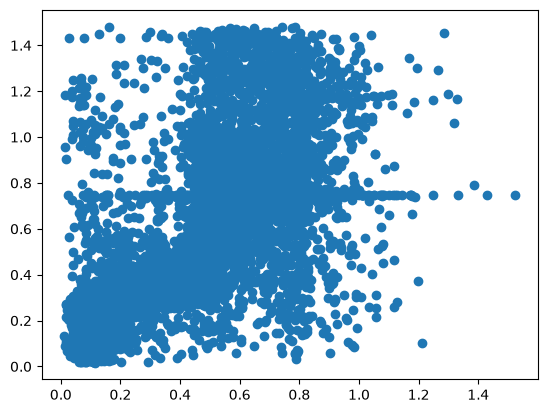

In [7]:
import matplotlib.pyplot as plt
plt.scatter(results['spec_redshift'][results['z_phot']!=-1], results['z500'][results['z_phot']!=-1])
plt.show()

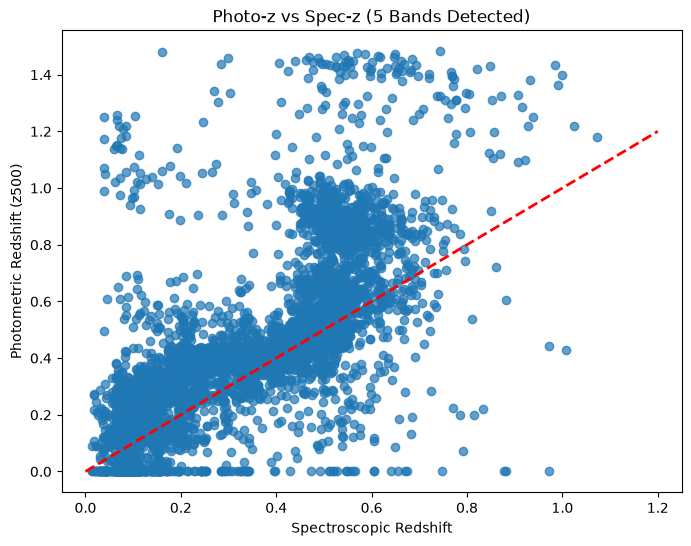

原本有 10000 個天體，過濾掉缺漏波段後剩下 5217 個天體。


In [8]:
import matplotlib.pyplot as plt

# 建立遮罩：要求 5 個波段的通量都大於 0 (都有實際探測到)
valid_mask = (results['F_g'] > 0) & (results['F_r'] > 0) & \
             (results['F_i'] > 0) & (results['F_z'] > 0) & (results['F_y'] > 0)

# 如果您有存 z500，請用 z500，否則用 z_phot
z_col = 'z500' if 'z500' in results.columns else 'z_phot'

# 確保 z_phot 有效且資料齊全
plot_df = results[(results[z_col] != -1) & valid_mask]

plt.figure(figsize=(8, 6))
plt.scatter(plot_df['spec_redshift'], plot_df[z_col], alpha=0.7)
plt.plot([0, 1.2], [0, 1.2], color='red', linestyle='--', linewidth=2) # 1:1 對角線參考

plt.xlabel('Spectroscopic Redshift')
plt.ylabel(f'Photometric Redshift ({z_col})')
plt.xlim(-0.05, 1.25)
plt.title('Photo-z vs Spec-z (5 Bands Detected)')
plt.show()

print(f"原本有 {len(results)} 個天體，過濾掉缺漏波段後剩下 {len(plot_df)} 個天體。")


清洗完成！準備使用 5217 個星系進行機器學習訓練。


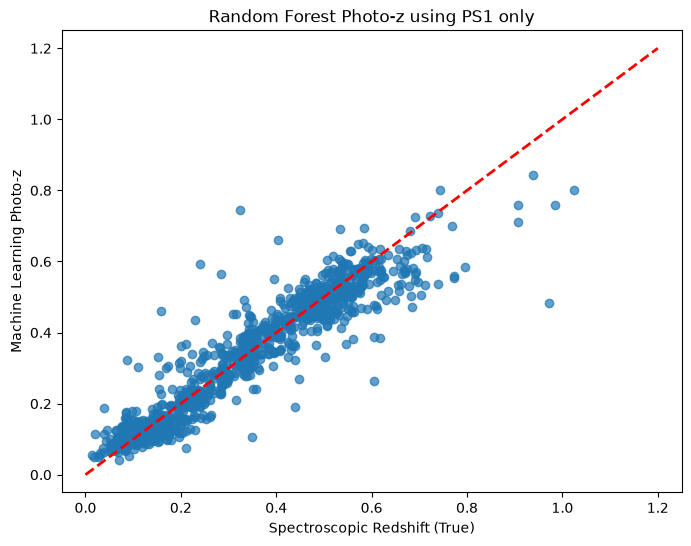

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. 準備您的數據
# 將需要的星等與目標值提取出來
ml_data = plot_df[['gMeanApMag', 'rMeanApMag', 'iMeanApMag', 'zMeanApMag', 'yMeanApMag', 'spec_redshift']].copy()

# 計算特徵顏色
ml_data['g-r'] = ml_data['gMeanApMag'] - ml_data['rMeanApMag']
ml_data['r-i'] = ml_data['rMeanApMag'] - ml_data['iMeanApMag']
ml_data['i-z'] = ml_data['iMeanApMag'] - ml_data['zMeanApMag']
ml_data['z-y'] = ml_data['zMeanApMag'] - ml_data['yMeanApMag']

# ================= 關鍵步驟：資料清洗 =================
# 1. 清除任何包含 NaN (缺失值) 的星系資料
ml_data = ml_data.dropna()
# 2. 確保只留下有真實光譜紅移的資料 (排除 -1 或是 0 的無效紅移)
ml_data = ml_data[ml_data['spec_redshift'] > 0]
# ===================================================

# 分離特徵 (X) 與目標 (y)
features = ml_data.drop(columns=['spec_redshift'])
target = ml_data['spec_redshift']

print(f"清洗完成！準備使用 {len(ml_data)} 個星系進行機器學習訓練。")

# 2. 切分訓練集與測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 3. 訓練隨機森林模型
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 4. 預測與畫圖
y_pred = rf.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 1.2], [0, 1.2], color='red', linestyle='--', linewidth=2)
plt.xlabel('Spectroscopic Redshift (True)')
plt.ylabel('Machine Learning Photo-z')
plt.title('Random Forest Photo-z using PS1 only')
plt.xlim(-0.05, 1.25)
plt.ylim(-0.05, 1.25)
plt.show()
